# Year-1 vs Year-2 Cold-Start Prediction within Geographic Clusters

**Goal.** Treat each site as a *brand-new* opening and predict its first two years of
KPIs purely from the **other sites in its 20 km cluster** — then measure how the
prediction holds up in **Year 1 (months 1–12)** vs **Year 2 (months 13–24)**.

**Design (chosen):**
- **Timeline = site age.** Each site is re-indexed so month 0 = its first month of
  data; we learn the *typical age trajectory* of a cluster, i.e. how sites ramp.
- **Cold-start decay.** A held-out site contributes *no* history — it is predicted
  only from its cluster-mates' trajectories at the same age (leave-one-site-out
  cross-validation, one fold per site). We then compare Year-1 vs Year-2 error.
- **Clusters = geographic 20 km** complete-linkage neighbourhoods (KPI-agnostic).
- **Weighting = inverse-distance (IDW)** — a new site has no history, so cluster-mates
  are weighted only by how close they are.
- **Baseline = global age curve** (the average trajectory of *all* sites by age,
  ignoring the cluster). Uplift > 0 means the local cluster beats the global average.

The 5 KPIs: membership_purchased_count, membership_wash_count, asp_per_membership,
retail_wash_count, asp_per_retail_wash.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# make the project's src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_all
from src.neighbours import haversine_km_vec
from src import config as C

plt.rcParams["figure.dpi"] = 110
KPIS   = C.TARGET_KPIS
LABELS = C.KPI_LABELS
MAXAGE = 24                      # two years of site age

ds = load_all()
sites, panels, month_axis = ds.sites.copy(), ds.panels, ds.month_axis
print(f"{len(sites):,} sites | {len(month_axis)} calendar months | KPIs: {KPIS}")

1,674 sites | 27 calendar months | KPIs: ['membership_purchased_count', 'membership_wash_count', 'asp_per_membership', 'retail_wash_count', 'asp_per_retail_wash']


## 1. Geographic 20 km clusters
Complete-linkage agglomerative clustering with a hard 20 km diameter cap (same
recipe as `cluster_pattern.ipynb`). We keep clusters with **≥2 sites** so every
held-out site has at least one neighbour to learn from.

In [2]:
Dkm = pairwise_distances(np.radians(sites[["lat", "lon"]].to_numpy()),
                         metric="haversine") * C.EARTH_KM
labels = AgglomerativeClustering(
    n_clusters=None, distance_threshold=C.BUFFER_KM,
    metric="precomputed", linkage="complete").fit(Dkm).labels_
sites["cluster"] = labels

vc = sites["cluster"].value_counts()
multi = vc[vc >= 2].index
sites["cluster"] = sites["cluster"].where(sites["cluster"].isin(multi), -1)
si = sites.set_index("site_uid")

print(f"clusters with >=2 sites : {len(multi)}")
print(f"sites inside a cluster   : {(sites.cluster >= 0).sum():,} / {len(sites):,}")
print(f"cluster size: median {int(vc[vc>=2].median())}, max {int(vc.max())}")

clusters with >=2 sites : 368
sites inside a cluster   : 1,305 / 1,674
cluster size: median 3, max 21


## 2. Re-index every site by AGE (months since opening)
`AGE[kpi]` is a `site_uid × age(0..23)` matrix. Age 0 is each site's first month,
so column *t* is "what sites look like *t* months after opening" — the quantity a
new site actually cares about.

In [3]:
def age_frame(kpi):
    p = panels[kpi]
    rows = {}
    for uid, row in p.iterrows():
        s = row.dropna()
        if s.empty:
            continue
        first = s.index.min()
        age = (s.index.year - first.year) * 12 + (s.index.month - first.month)
        ser = pd.Series(s.values, index=age)
        rows[uid] = ser[~ser.index.duplicated()].reindex(range(MAXAGE))
    return pd.DataFrame(rows).T

AGE    = {k: age_frame(k) for k in KPIS}
GLOBAL = {k: AGE[k].mean(axis=0) for k in KPIS}     # baseline age curve (all sites)

cov = AGE["retail_wash_count"].notna().sum(axis=0)
print("sites with data at age  0 :", int(cov.get(0, 0)), "(can score Year 1 start)")
print("sites with data at age 11 :", int(cov.get(11, 0)))
print("sites with full 24 months :", int(AGE['retail_wash_count'].iloc[:, 23].notna().sum()),
      "(can score Year 2)")

sites with data at age  0 : 1674 (can score Year 1 start)
sites with data at age 11 : 1127
sites with full 24 months : 591 (can score Year 2)


## 3. Cold-start prediction = IDW blend of cluster-mates at the same age
For a held-out site we take the *other* sites in its cluster, weight them by
inverse distance, and average their value at each age. Per-age weights are
renormalised over the mates that actually have data at that age.

In [4]:
def predict_holdout(uid, kpi, agg="idw"):
    c = si.loc[uid, "cluster"]
    if c < 0:
        return None
    mates = si[(si.cluster == c) & (si.index != uid)]
    A = AGE[kpi].reindex(mates.index)
    if A.dropna(how="all").empty:
        return None
    d = haversine_km_vec(si.loc[uid, "lat"], si.loc[uid, "lon"],
                         mates.lat.values, mates.lon.values)
    w = 1.0 / (d + C.IDW_EPS_KM) if agg == "idw" else np.ones(len(mates))
    V = A.to_numpy(float)
    mask = ~np.isnan(V)
    W = w[:, None] * mask
    den = W.sum(axis=0)
    pred = np.where(den > 0, np.nansum(np.where(mask, W * V, 0.0), axis=0) / den, np.nan)
    return pd.Series(pred, index=A.columns)

# sanity: one held-out site
demo = si[si.cluster >= 0].index[0]
print("demo prediction (retail_wash_count) for", demo)
print(predict_holdout(demo, "retail_wash_count").round(0).head(6).to_dict())

demo prediction (retail_wash_count) for 360 Car Wash__1
{0: 1302.0, 1: 2480.0, 2: 2286.0, 3: 3000.0, 4: 2383.0, 5: 3503.0}


## 4. Leave-one-site-out cross-validation across every cluster
For each held-out site × KPI we record the predicted and actual value at every
age, plus the global-baseline value, then tag each age as Year 1 or Year 2.

In [5]:
def smape(a, p):
    return float(np.mean(2 * np.abs(p - a) / (np.abs(p) + np.abs(a) + 1e-9)))

year_rows, age_rows = [], []
for uid in si[si.cluster >= 0].index:
    for kpi in KPIS:
        pred = predict_holdout(uid, kpi)
        if pred is None:
            continue
        actual, base = AGE[kpi].loc[uid], GLOBAL[kpi]
        # per-age long records (for the decay curve)
        for age in range(MAXAGE):
            a, p = actual.iloc[age], pred.iloc[age]
            if np.isfinite(a) and np.isfinite(p):
                age_rows.append((kpi, age, abs(p - a),
                                 2 * abs(p - a) / (abs(p) + abs(a) + 1e-9)))
        # per-year aggregates
        for yr, (lo, hi) in [(1, (0, 12)), (2, (12, 24))]:
            a, p, g = actual.iloc[lo:hi], pred.iloc[lo:hi], base.iloc[lo:hi]
            m = a.notna() & p.notna()
            if m.sum() < C.MIN_OVERLAP_MONTHS:
                continue
            av, pv, gv = a[m].to_numpy(), p[m].to_numpy(), g[m].to_numpy()
            r = pearsonr(av, pv)[0] if av.std() > 0 and pv.std() > 0 else np.nan
            year_rows.append(dict(site=uid, kpi=kpi, year=yr, n=int(m.sum()),
                                  mae=np.mean(np.abs(pv - av)), smape=smape(av, pv),
                                  r=r, mae_base=np.mean(np.abs(gv - av))))

res = pd.DataFrame(year_rows)
age_err = pd.DataFrame(age_rows, columns=["kpi", "age", "abs_err", "smape"])
print(f"scored {len(res):,} (site, KPI, year) folds across {res.site.nunique():,} sites")

scored 9,730 (site, KPI, year) folds across 1,227 sites


## 5. Year-1 vs Year-2 scorecard
`sync_r` = median Pearson correlation between the predicted and actual age curve
("how synced they move"). `uplift%` = how much the local cluster beats the global
baseline on MAE.

In [6]:
summary = (res.groupby(["kpi", "year"])
           .agg(n_folds=("mae", "size"),
                MAE=("mae", "median"),
                sMAPE=("smape", "median"),
                sync_r=("r", "median"),
                MAE_base=("mae_base", "median"))
           .reset_index())
summary["uplift_%"] = (100 * (summary.MAE_base - summary.MAE) / summary.MAE_base).round(1)
summary["label"] = summary.kpi.map(LABELS)
summary = summary.round({"MAE": 1, "sMAPE": 3, "sync_r": 3, "MAE_base": 1})
order = ["retail_wash_count", "membership_wash_count", "membership_purchased_count",
         "asp_per_membership", "asp_per_retail_wash"]
summary["kpi"] = pd.Categorical(summary.kpi, order, ordered=True)
summary = summary.sort_values(["kpi", "year"])
summary[["label", "year", "n_folds", "MAE", "sMAPE", "sync_r", "MAE_base", "uplift_%"]]

,label,year,n_folds,MAE,sMAPE,sync_r,MAE_base,uplift_%
8,Retail washes,1,1227,1195.1,0.477,0.485,1152.9,-3.7
9,Retail washes,2,719,1044.6,0.385,0.795,1074.9,2.8
6,Membership washes,1,1227,2295.9,0.662,0.547,2832.8,19.0
7,Membership washes,2,719,2363.4,0.549,0.792,2859.3,17.3
4,Memberships sold,1,1227,884.8,0.706,0.495,992.3,10.8
5,Memberships sold,2,719,894.4,0.601,0.518,1053.0,15.1
0,ASP / membership ($),1,1227,4.5,0.163,0.357,4.7,4.3
1,ASP / membership ($),2,719,3.4,0.109,0.308,4.5,23.3
2,ASP / retail wash ($),1,1227,3.2,0.261,0.276,2.8,-13.8
3,ASP / retail wash ($),2,719,3.0,0.215,0.171,2.7,-12.5


## 6. Plot — Year 1 vs Year 2 by KPI
Left: trend-shape sync (Pearson r, comparable across KPIs). Right: error rate
(sMAPE, lower is better). Most volume KPIs get **more** predictable in Year 2 —
the ramp-up noise of a new site settles into the cluster's mature pattern.

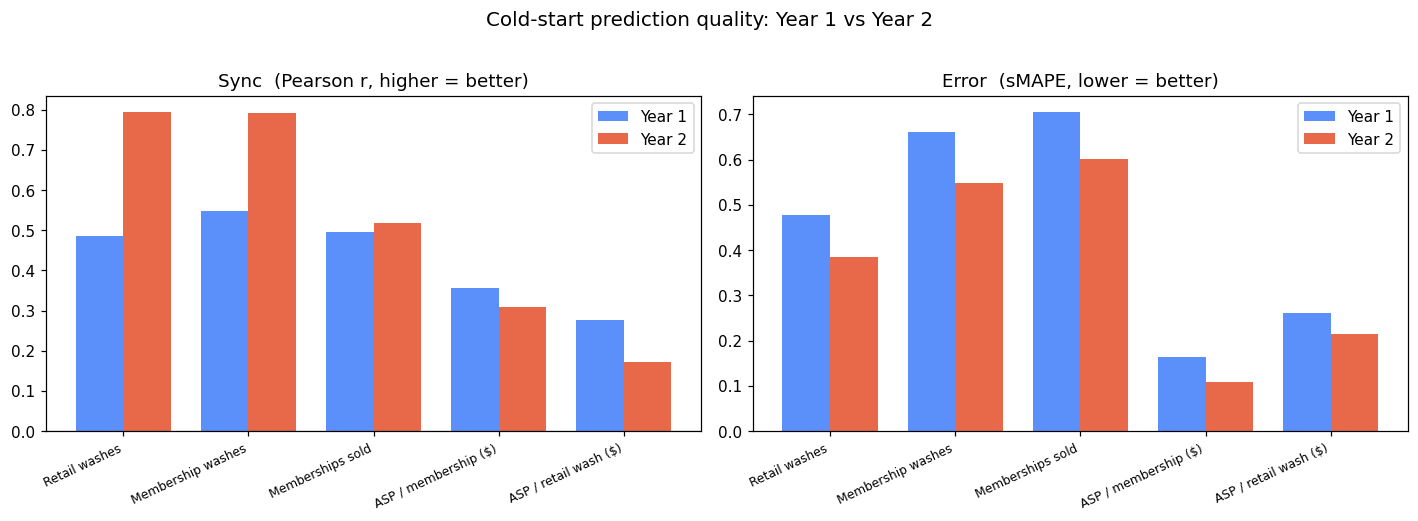

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
labs = [LABELS[k] for k in order]
y1 = summary[summary.year == 1].set_index("kpi").reindex(order)
y2 = summary[summary.year == 2].set_index("kpi").reindex(order)
x = np.arange(len(order)); wd = 0.38

for ax, col, title in [(axes[0], "sync_r", "Sync  (Pearson r, higher = better)"),
                       (axes[1], "sMAPE", "Error  (sMAPE, lower = better)")]:
    ax.bar(x - wd/2, y1[col], wd, label="Year 1", color="#5B8FF9")
    ax.bar(x + wd/2, y2[col], wd, label="Year 2", color="#E8684A")
    ax.set_xticks(x); ax.set_xticklabels(labs, rotation=25, ha="right", fontsize=8)
    ax.set_title(title); ax.legend()
    if col == "sync_r":
        ax.axhline(0, color="grey", lw=.8)
fig.suptitle("Cold-start prediction quality: Year 1 vs Year 2", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 7. Plot — error decay over site age
Median sMAPE at each month of age (0–23), per KPI. The dashed line marks the
Year-1 / Year-2 boundary. Flat-or-falling curves mean the cluster keeps predicting
well as the site matures; rising curves mean drift.

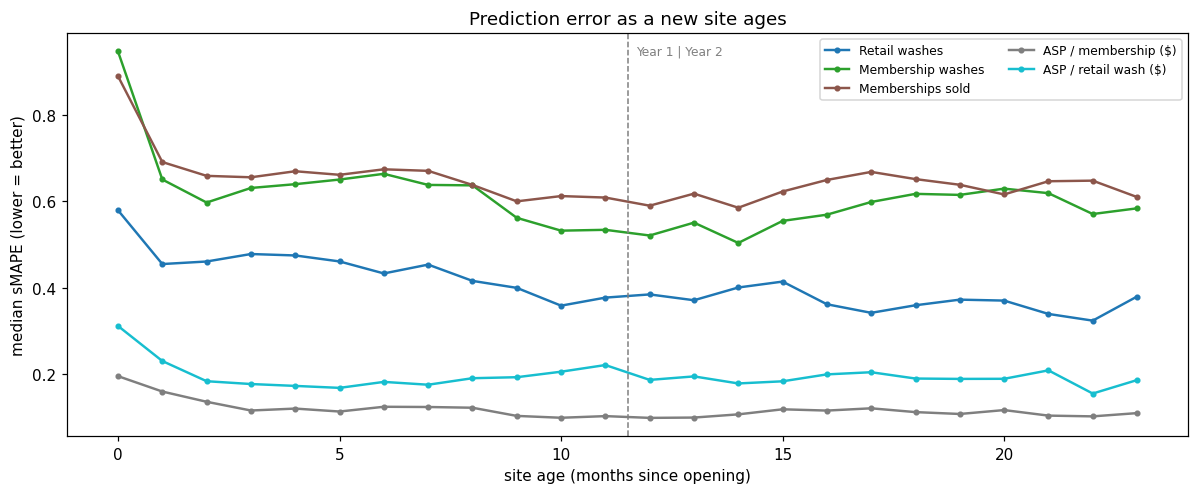

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = plt.cm.tab10(np.linspace(0, 1, len(order)))
for k, c in zip(order, colors):
    g = age_err[age_err.kpi == k].groupby("age")["smape"].median()
    ax.plot(g.index, g.values, marker="o", ms=3, lw=1.6, color=c, label=LABELS[k])
ax.axvline(11.5, color="grey", ls="--", lw=1)
ax.text(11.7, ax.get_ylim()[1]*0.95, "Year 1 | Year 2", fontsize=8, color="grey")
ax.set_xlabel("site age (months since opening)")
ax.set_ylabel("median sMAPE (lower = better)")
ax.set_title("Prediction error as a new site ages")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 8. Plot — example sites: predicted vs actual, split Year 1 / Year 2
Four held-out sites with a full 24-month history. **Grey** = the cluster-mates the
prediction is built from, **red dashed** = cold-start prediction, **black** = the
site's actual trajectory. Shaded band = Year 2.

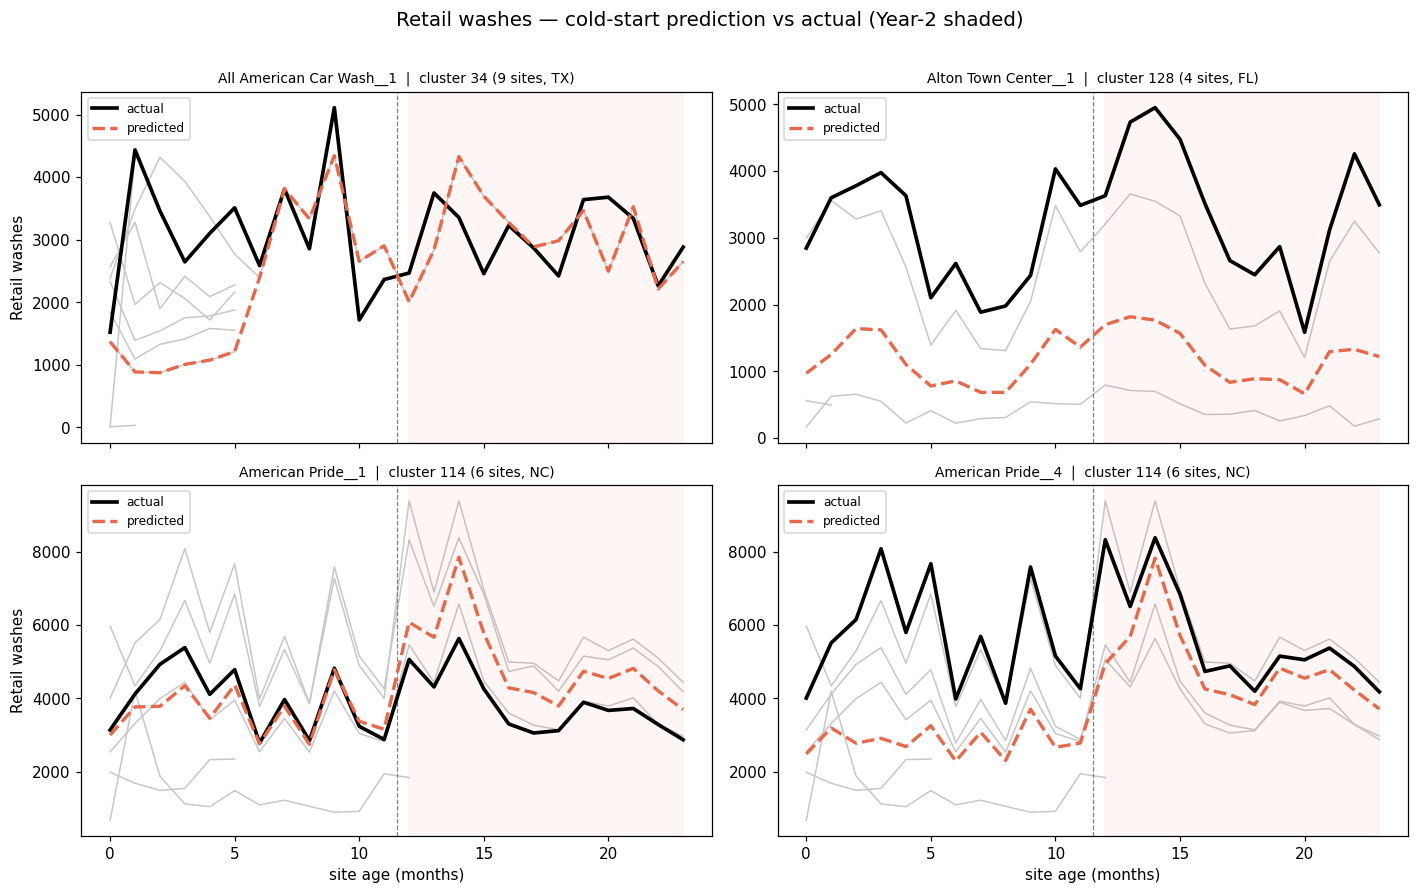

In [9]:
KPI_SHOW = "retail_wash_count"
full = AGE[KPI_SHOW].iloc[:, 23].notna()
cand = [u for u in si[(si.cluster >= 0)].index
        if u in full.index and full.loc[u] and (si.loc[u, "cluster"] >= 0)
        and (si.cluster == si.loc[u, "cluster"]).sum() >= 4]
examples = cand[:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, uid in zip(axes.ravel(), examples):
    c = si.loc[uid, "cluster"]
    mates = si[(si.cluster == c) & (si.index != uid)].index
    for mid in mates:
        ax.plot(range(MAXAGE), AGE[KPI_SHOW].loc[mid].values,
                color="0.78", lw=1, zorder=1)
    pred = predict_holdout(uid, KPI_SHOW)
    ax.plot(range(MAXAGE), AGE[KPI_SHOW].loc[uid].values, color="black",
            lw=2.4, label="actual", zorder=3)
    ax.plot(range(MAXAGE), pred.values, color="#E8684A", lw=2.2, ls="--",
            label="predicted", zorder=3)
    ax.axvspan(12, MAXAGE - 1, color="#E8684A", alpha=0.06)
    ax.axvline(11.5, color="grey", ls="--", lw=.8)
    ax.set_title(f"{uid}  |  cluster {int(c)} ({len(mates)+1} sites, {si.loc[uid,'state']})",
                 fontsize=9)
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("site age (months)")
for ax in axes[:, 0]:
    ax.set_ylabel(LABELS[KPI_SHOW])
fig.suptitle(f"{LABELS[KPI_SHOW]} — cold-start prediction vs actual (Year-2 shaded)",
             y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Wash counts are the learnable signal.** Retail and membership washes carry the
  strongest within-cluster sync, and it **improves in Year 2** — a new site's first
  months are noisy ramp-up, but once mature it tracks its cluster closely.
- **The cluster beats the global average** (positive uplift) for the volume metrics,
  confirming geography adds real information beyond "the average site".
- **Retail ASP stays unpredictable** from neighbours (low sync, negative uplift) —
  pricing is set per-operator, not by geography, consistent with the clustering study.
- **Practical read for a new site:** expect Year-1 numbers to be the hardest to call
  (ramp-up); the cluster gives a progressively better estimate of the mature
  (Year-2) run-rate, especially for wash volumes.